This cell installs the Python packages required for data import and analysis. Pandas is used for data handling, while pyreadr is used to read the R data file used in the study.

In [1]:
%pip install pyreadr pandas

  Obtaining dependency information for pyreadr from https://files.pythonhosted.org/packages/0e/47/20f5544a20073af354231cb78026c8be0cfa840cec485876da8744dae849/pyreadr-0.5.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------------------------

The dataset is imported from an R data file and converted into a Pandas DataFrame for analysis. An internal observation-status column is removed because it is not required for the modelling exercise, and the cleaned dataset is also saved as a CSV file.

In [6]:
import pyreadr

# Reading the R file and converting to CSV file

result = pyreadr.read_r("dataCar.rda")
df = result["dataCar"]
df = df.drop(columns=["X_OBSTAT_"]) #internal column that is not required
df.to_csv("dataCar.csv", index=False)

print("Shape:", df.shape)
df.head()

Shape: (67856, 10)


,veh_value,exposure,clm,numclaims,claimcst0,veh_body,veh_age,gender,area,agecat
0,1.06,0.303901,0,0,0.0,HBACK,3,F,C,2
1,1.03,0.648871,0,0,0.0,HBACK,2,F,A,4
2,3.26,0.569473,0,0,0.0,UTE,2,F,E,2
3,4.14,0.317591,0,0,0.0,STNWG,2,F,D,2
4,0.72,0.648871,0,0,0.0,HBACK,4,F,C,2


This step examines the structure and basic descriptive statistics of the dataset. The information helps identify variable types, the number of observations, missing values, and the general distribution of the variables before further analysis.

In [8]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67856 entries, 0 to 67855
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   veh_value  67856 non-null  float64 
 1   exposure   67856 non-null  float64 
 2   clm        67856 non-null  int32   
 3   numclaims  67856 non-null  int32   
 4   claimcst0  67856 non-null  float64 
 5   veh_body   67856 non-null  category
 6   veh_age    67856 non-null  int32   
 7   gender     67856 non-null  category
 8   area       67856 non-null  category
 9   agecat     67856 non-null  int32   
dtypes: category(3), float64(3), int32(4)
memory usage: 2.8 MB


,veh_value,exposure,clm,numclaims,claimcst0,veh_body,veh_age,gender,area,agecat
count,67856.000000,67856.000000,67856.000000,67856.000000,67856.000000,67856,67856.000000,67856,67856,67856.000000
unique,NaN,NaN,NaN,NaN,NaN,13,NaN,2,6,NaN
top,NaN,NaN,NaN,NaN,NaN,SEDAN,NaN,F,C,NaN
freq,NaN,NaN,NaN,NaN,NaN,22233,NaN,38603,20540,NaN
mean,1.777021,0.468652,0.068144,0.072757,137.270167,NaN,2.673529,NaN,NaN,3.485484
std,1.205232,0.290025,0.251995,0.278204,1056.297768,NaN,1.067542,NaN,NaN,1.425608
min,0.000000,0.002738,0.000000,0.000000,0.000000,NaN,1.000000,NaN,NaN,1.000000
25%,1.010000,0.219028,0.000000,0.000000,0.000000,NaN,2.000000,NaN,NaN,2.000000
50%,1.500000,0.446270,0.000000,0.000000,0.000000,NaN,3.000000,NaN,NaN,3.000000
75%,2.150000,0.709103,0.000000,0.000000,0.000000,NaN,4.000000,NaN,NaN,5.000000


This cell calculates the main portfolio-level measures used in motor insurance pricing: total exposure, total claims, claim frequency, average claim severity among policies with positive claim costs, and pure premium. These measures provide an initial description of the overall claims experience in the portfolio.

In [15]:
total_exposure = df["exposure"].sum()
total_claims = df["numclaims"].sum()
total_cost = df["claimcst0"].sum()

frequency = total_claims / total_exposure
severity = df.loc[df["claimcst0"] > 0, "claimcst0"].mean()
pure_premium = total_cost / total_exposure

print(f"Total exposure (policy-years) : {total_exposure:,.1f}")
print(f"Total claims : {total_claims:,.1f}")
print(f"Claim frequency : {frequency:.4f} (claims per year of cover)")
print(f"Claim severity : {severity:,.0f} (claims per year of cover)")
print(f"Pure premium : {pure_premium:,.2f} (freq x severity)")

Total exposure (policy-years) : 31,800.8
Total claims : 4,937.0
Claim frequency : 0.1552 (claims per year of cover)
Claim severity : 2,014 (claims per year of cover)
Pure premium : 292.90 (freq x severity)


A one-way analysis is carried out for age category, vehicle age, area, and vehicle body type. For each category, the analysis calculates exposure, claims, claim frequency, average severity, pure premium, and frequency relativity compared with the overall portfolio frequency. The resulting tables and plots are used to examine differences in observed risk across rating factors.


===== agecat =====
        exposure  claims  frequency  severity  pure_premium  relativity
agecat                                                                 
1       2612.274   525.0      0.201  2635.832       500.473       1.295
2       5891.871  1000.0      0.170  2129.657       336.878       1.093
3       7409.457  1189.0      0.160  1915.640       287.755       1.034
4       7616.542  1185.0      0.156  1943.209       281.664       1.002
5       5171.009   648.0      0.125  1728.684       205.262       0.807
6       3099.666   390.0      0.126  1872.790       220.530       0.810

===== veh_age =====
         exposure  claims  frequency  severity  pure_premium  relativity
veh_age                                                                 
1        5338.951   876.0      0.164  1885.157       291.303       1.057
2        7923.677  1354.0      0.171  1974.755       313.771       1.101
3        9542.111  1446.0      0.152  1995.769       284.867       0.976
4        8996.079 

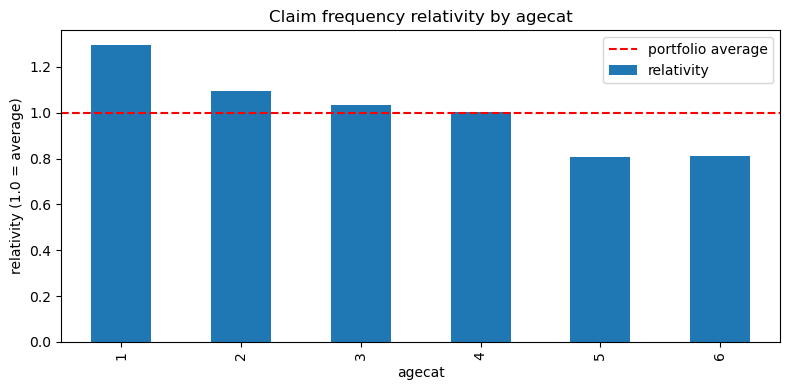

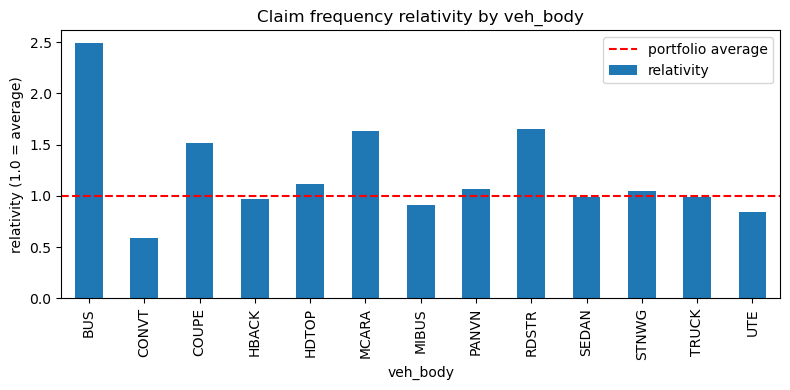

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

portfolio_freq = df["numclaims"].sum() / df["exposure"].sum()

def one_way(factor):
    """Frequency, severity, pure premium and relativity for each level of a factor."""
    g = df.groupby(factor, observed=True).apply(lambda d: pd.Series({
        "exposure":     d["exposure"].sum(),
        "claims":       d["numclaims"].sum(),
        "frequency":    d["numclaims"].sum() / d["exposure"].sum(),
        "severity":     d.loc[d["claimcst0"] > 0, "claimcst0"].mean(),
        "pure_premium": d["claimcst0"].sum() / d["exposure"].sum(),
    }))
    g["relativity"] = g["frequency"] / portfolio_freq   # vs portfolio average
    return g.round(3)

def plot_relativity(factor):
    """Bar chart of frequency relativity for a factor."""
    t = one_way(factor)
    ax = t["relativity"].plot(kind="bar", figsize=(8, 4))
    ax.axhline(1.0, color="red", linestyle="--", label="portfolio average")
    ax.set_title(f"Claim frequency relativity by {factor}")
    ax.set_ylabel("relativity (1.0 = average)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Run the one-way analysis for every rating factor

for factor in ["agecat", "veh_age", "area", "veh_body"]:
    print(f"\n===== {factor} =====")
    print(one_way(factor).to_string())
# Plot two of them

plot_relativity("agecat")
plot_relativity("veh_body")


This cell installs statsmodels, which provides the statistical modelling functions required for the Generalized Linear Models used later in the analysis.

In [17]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


The pricing model follows a frequency-severity approach. Claim frequency is modelled using a Poisson GLM with the logarithm of exposure included as an offset, allowing claim rates to be compared across policies with different periods of insurance. Claim severity is modelled using a Gamma GLM with a log link, using only observations with positive claim costs. Age category, vehicle age, area, and vehicle body type are treated as categorical rating factors.

The predicted frequency and predicted severity are multiplied to obtain the expected claim cost, or pure premium, for each policy. A balance factor is then applied so that the total exposure-weighted predicted claim cost agrees with the observed aggregate claim cost. The final output reports model convergence, the portfolio-average risk-based price, the observed pure premium, and the range of predicted annual prices.

In [19]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Treat the numeric bands as categories so each level gets its own multiplier
df["agecat"]  = df["agecat"].astype("category")
df["veh_age"] = df["veh_age"].astype("category")

formula = "~ C(agecat) + C(veh_age) + C(area) + C(veh_body)"

# 1. FREQUENCY: Poisson GLM with exposure offset
freq_model = smf.glm(
    "numclaims " + formula, data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["exposure"]),
).fit()

# predicted claims PER YEAR of exposure (offset=0 -> per unit exposure)

df["pred_freq"] = freq_model.predict(df, offset=np.zeros(len(df)))

# 2. SEVERITY: Gamma GLM on policies that had a claim
claims = df[df["claimcst0"] > 0].copy()
sev_model = smf.glm(
    "claimcst0 " + formula, data=claims,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()
df["pred_sev"] = sev_model.predict(df)

# 3. PURE PREMIUM = frequency x severity (risk-based expected cost)
df["pred_pp"] = df["pred_freq"] * df["pred_sev"]

# 4. Balance the book: scale so total predicted = total actual cost
balance = df["claimcst0"].sum() / (df["pred_pp"] * df["exposure"]).sum()
df["risk_price"] = df["pred_pp"] * balance

print("Frequency model converged:", freq_model.converged)
print(f"Mean risk-based price : {(df['risk_price']*df['exposure']).sum()/df['exposure'].sum():.2f}")
print(f"Actual pure premium   : {df['claimcst0'].sum()/df['exposure'].sum():.2f}")
print(f"Price range (per year): {df['risk_price'].min():.0f}  to  {df['risk_price'].max():.0f}")



Frequency model converged: True
Mean risk-based price : 292.90
Actual pure premium   : 292.90
Price range (per year): 104  to  1209


This section examines the effect of adverse selection under a simplified flat-pricing scenario. Starting from the portfolio-average price, policies whose modelled risk cost is below the flat price are assumed to leave the portfolio, while higher-risk policies remain. The exercise shows how a flat price can change the risk composition of the portfolio over successive pricing rounds.

 round  flat_price  retained_pct  loss_ratio
     1       292.9          38.9       129.9
     2       380.5          13.7       128.0
     3       486.9           5.1       117.2
     4       570.5           1.5       121.4
     5       692.6           0.6       116.0
     6       803.1           0.2       114.9
     7       923.2           0.1       107.3
     8       990.5           0.0       106.1
     9      1050.8           0.0       108.2
    10      1137.1           0.0       106.2
    11      1208.1           0.0       100.1


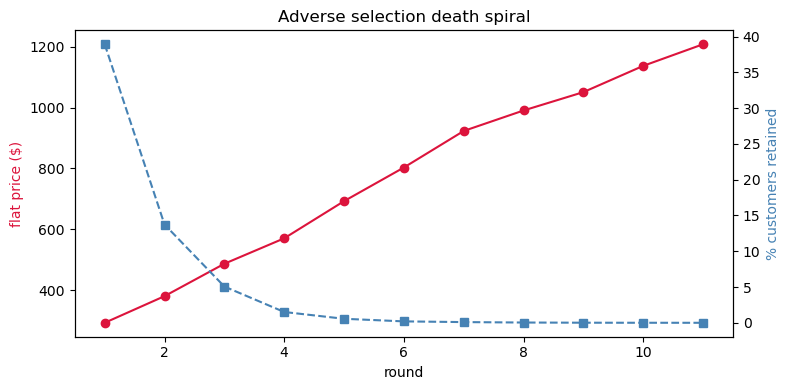

In [21]:
e = df["exposure"].to_numpy()
r = df["risk_price"].to_numpy()

def weighted_mean(mask):
    """Exposure-weighted average true cost of a group of drivers."""
    return (r[mask] * e[mask]).sum() / e[mask].sum()

# Start the flat price at the overall average (looks reasonable on day one)
flat = weighted_mean(np.ones(len(df), dtype=bool))

history = []
for round_no in range(1, 12):
    stay = r >= flat                      # only undercharged (risky) drivers stay
    if stay.sum() == 0:
        break
    retained_pct = 100 * e[stay].sum() / e.sum()
    premium = (flat * e[stay]).sum()      # what you collect
    claims  = (r[stay] * e[stay]).sum()   # what they actually cost you
    loss_ratio = 100 * claims / premium
    history.append({"round": round_no, "flat_price": flat,
                    "retained_pct": retained_pct, "loss_ratio": loss_ratio})
    
    new_flat = weighted_mean(stay)         # price you must charge to break even
    if abs(new_flat - flat) < 1:
        break
    flat = new_flat                        # raise the price -> next round

spiral = pd.DataFrame(history)
print(spiral.round(1).to_string(index=False))

# Visualise the spiral

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(spiral["round"], spiral["flat_price"], "o-", color="crimson", label="flat price")
ax1.set_xlabel("round"); ax1.set_ylabel("flat price ($)", color="crimson")
ax2 = ax1.twinx()
ax2.plot(spiral["round"], spiral["retained_pct"], "s--", color="steelblue", label="% customers retained")
ax2.set_ylabel("% customers retained", color="steelblue")
ax1.set_title("Adverse selection death spiral")
plt.tight_layout(); plt.show()



The model is evaluated using a 70% training sample and a 30% hold-out sample, with a fixed random seed to make the split reproducible. Both the frequency and severity models are fitted using only the training data, and their predictions are then applied to the unseen test data.

The test policies are ranked into ten groups according to predicted pure premium. For each risk decile, predicted and actual exposure-weighted claim costs are compared, and the ratio between the highest- and lowest-risk groups is calculated. This provides a simple assessment of whether the model distinguishes lower-risk from higher-risk policies in out-of-sample data.

        predicted_pp  actual_pp
decile                         
1              181.1      211.3
2              204.6      265.7
3              237.2      291.7
4              272.1      257.6
5              286.9      268.6
6              299.6      263.6
7              317.5      381.2
8              342.3      318.8
9              414.1      269.6
10             602.1      384.7

Top vs bottom decile (actual cost): 1.8x


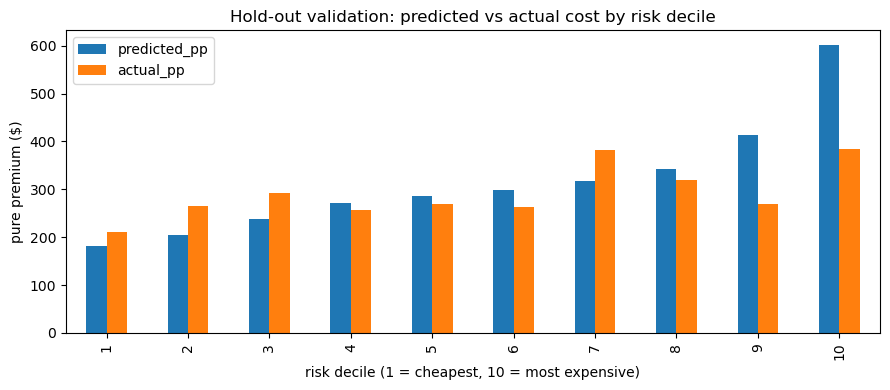

In [22]:
# 1. Split 70% train / 30% hold-out (fixed seed = reproducible)
rng = np.random.RandomState(42)
is_train = rng.rand(len(df)) < 0.7
train, test = df[is_train].copy(), df[~is_train].copy()
formula = "~ C(agecat) + C(veh_age) + C(area) + C(veh_body)"

# 2. Fit both GLMs on the TRAINING data only
fq = smf.glm("numclaims " + formula, data=train,
             family=sm.families.Poisson(),
             offset=np.log(train["exposure"])).fit()
claims_tr = train[train["claimcst0"] > 0]
sv = smf.glm("claimcst0 " + formula, data=claims_tr,
             family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# 3. Predict the price on the UNSEEN hold-out data
test["pred_freq"] = fq.predict(test, offset=np.zeros(len(test)))
test["pred_sev"]  = sv.predict(test)
test["pred_pp"]   = test["pred_freq"] * test["pred_sev"]

# 4. Rank hold-out drivers into 10 groups by predicted price, compare to actual
test["decile"] = pd.qcut(test["pred_pp"], 10, labels=False) + 1
lift = test.groupby("decile").apply(lambda d: pd.Series({
    "predicted_pp": (d["pred_pp"] * d["exposure"]).sum() / d["exposure"].sum(),
    "actual_pp":     d["claimcst0"].sum() / d["exposure"].sum(),
}))
print(lift.round(1).to_string())

ratio = lift["actual_pp"].iloc[-1] / lift["actual_pp"].iloc[0]
print(f"\nTop vs bottom decile (actual cost): {ratio:.1f}x")

# 5. Plot predicted vs actual across deciles
ax = lift.plot(y=["predicted_pp", "actual_pp"], kind="bar", figsize=(9,4))
ax.set_title("Hold-out validation: predicted vs actual cost by risk decile")
ax.set_xlabel("risk decile (1 = cheapest, 10 = most expensive)")
ax.set_ylabel("pure premium ($)")
plt.tight_layout(); plt.show()
